# Goal: Describe how differing interest groups influence customer purchasing decisions at a local game store in 2023

In [12]:
# imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
from scipy.stats import spearmanr
from scipy.stats import chi2_contingency

import project_wrangle as w
import explore as e

##  Wrangle

This project relies on transaction data from a local game store that was prepared in another repository. Items customers purchased were separated into one of nine categories based areas of interest in the gaming community and product type.

**Area of interest categories include:**
* Board Games 
* Role Playing Games
* Trading Card Games
* Minis Models
* Modeling Supplies
<a/>

**Support categories include:**
* Accessories
* Concessions
* Game Room Rentals
<a/>

**Items that could not be classified**
* Other
<a/>

For a detailed description of how that data was prepared including the criteria used for each category see [wrangle_lgs_data](https://github.com/Johndsalas/wrangle_lgs_data/tree/main).

### Project Specific Preparation

* Read in transaction data
* Drop unused columns
* Drop rows containing non-payment data
* Drop rows where customer ID is unknown
* Drop rows where transaction occurred outside of 2023
* Aggregate net sales and item count rows on customer id to get totals for the year
* Drop customer id
* After preparation the data frame contains 1,586 rows and 9 columns
* Each row represents a customer who made a purchase in 2023
* 8 columns describe the number of items purchased by a customer in a given category in 2023
* 1 column describes a customers total net spending in 2023

                                                     Data Dictionary


|Column|Definition|
|------|----------|
|'Category Name'|Number of items purchased from this category in 2023| 
|Net Sales|Total money spent excluding tax and discounts in 2023|

In [13]:
# get prepared data
df = w.get_prepared_profiles_data()

## Explore 

### What does an average customer's spending habits look like?

In [14]:
# get abridged describe table
e.get_desc(df)

,accessories,board_games,concessions,modeling_supplies,role_playing_games,minis_models,trading_card_games,game_room_rental,net_sales
mean,1.715006,0.474149,4.362547,1.569987,0.165826,0.541614,2.228247,0.059899,172.634332
std,4.503849,1.391602,18.823379,8.263589,0.877833,2.303441,7.990032,0.564630,442.719224


* Each category has a standard deviation that is several times the mean of that group
* This suggests a large range and high variance in each group
* Because of this a mean value may provide a distorted representation of each group
* It may be beneficial to identify customer groupings where variance is less severe

### How many customers does each category appeal to? 

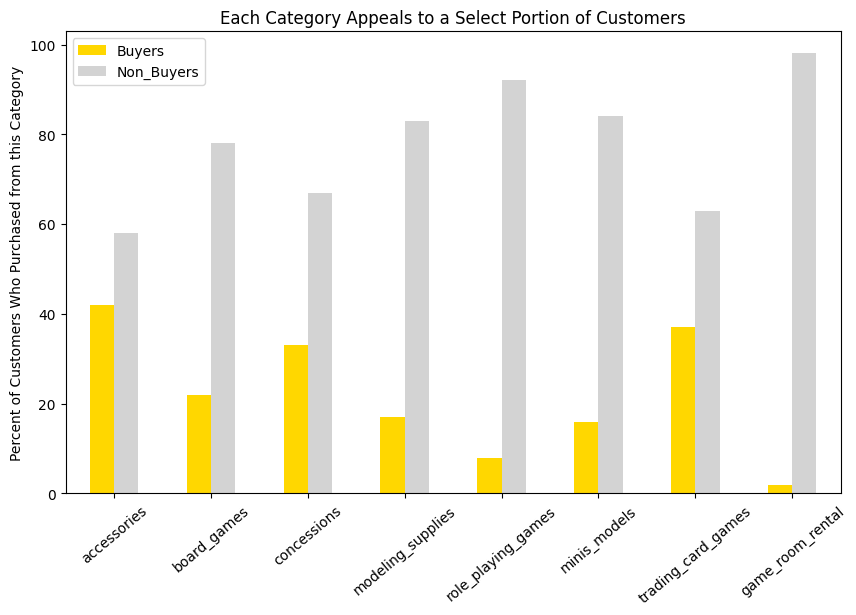

In [15]:
# get appeal chart
e.cat_appeal(df)

Each category only appeals to a select amount of customers
    
Interest Categories
* Trading Card Games 37%
* Board Games 22%
* Modeling Supplies 17%
* Minis Models 16%
* Role Playing Games 8%

Support Categories
* Accessories 42%
* Concessions 33%
* Game Room Rental 2%

#### Summary 
* Interest categories appeal to roughly 1/3 of customers or less, likely due to specialized customer interests 
* Accessories is the highest appeal category, likely due to interest categories driving sales of related accessories

### Is there a relationship between customers who buy products in one category and customers who buy products in a different category?

Based on a chi-square test, using an alpha of .05, and the odds ratio of buyers to non-buyers in each category the following relationships exist between these categories:

Customers who bought Board Games
* 78% More likely to buy role playing games
* 61% Less likely to buy trading card games 

Customers who bought Role Playing Games
* 4.23 Times as likely to buy minis models
* 2.59 Times as likely to buy accessories
* 2.21 Times as likely to buy modeling supplies
* 78% More likely to buy board games
* 80% More likely to buy concessions
* 40% decreased odds of buying trading card games

Customers who bought Minis Models
* 8.45 Times as likely to buy modeling supplies
* 4.23 Times as likely to buy Role Playing Games
* 75% More likely to buy concessions
* 50% Less likely to buy trading card games

Customers who bought Trading Card Games
* 88% More likely to buy accessories
* 47% More likely to buy concessions
* 61% Less likely to buy board games
* 61% Less likely to buy modeling supplies
* 50% Less likely to buy minis models 
* 40% Less likely to buy role playing games

Customers who bought Modeling Supplies
* 8.45 Times as likely to buy minis models
* 2.21 Times as likely to buy role playing games
* 65% More likely to buy concessions
* 61% less likely to buy Trading Card Games 

#### Summary of Interest Categories

Board Gamers
* Most diversified Interests
* Not many strong relationships to other categories
* More likely to buy role playing games
* Less likely buy trading card games

Trading Card Gamers
* Least diversified interests
* Less likely to buy products in other interest categories
* More likely to buy accessories and concessions

Role Playing Gamers
* Likely a major driver of sales in other categories
* Nearly 3 times as likely to buy accessories
* Over 4 times as likely to buy minis models 
* 2 times as likely to buy modeling supplies
* More likely to buy board games and concessions
* Less likely to buy trading card games

Minis Models
* Comprised of “war gaming” models and models that support role playing games
* Likely a driver of modeling supplies and partially driven by role playing games
* Over 8 times as likely to buy modeling supplies
* More likely to buy concessions
* Less likely to buy trading card games

Modeling supplies
* Likely driven by minis models
* Over 8 times as likely to buy minis models
* Less likely to buy trading card games

 ### Chi-square test and odds ratio readouts (significant findings only)

In [16]:
# get chi-square test and odds ratio readouts
e.get_rel(df)

bought_accessories and bought_concessions
--------------------------------------------------------
Chi-Square P-Value: 0.00022898142106283562
Odds Ratio: 1.49

bought_accessories and bought_role_playing_games
--------------------------------------------------------
Chi-Square P-Value: 2.637590995781412e-07
Odds Ratio: 2.59

bought_accessories and bought_trading_card_games
--------------------------------------------------------
Chi-Square P-Value: 2.6189298764791124e-09
Odds Ratio: 1.88

bought_board_games and bought_role_playing_games
--------------------------------------------------------
Chi-Square P-Value: 0.003992273243111018
Odds Ratio: 1.78

bought_board_games and bought_trading_card_games
--------------------------------------------------------
Chi-Square P-Value: 3.903131004282979e-11
Odds Ratio: 0.39

bought_concessions and bought_modeling_supplies
--------------------------------------------------------
Chi-Square P-Value: 0.0002876863942808126
Odds Ratio: 1.65

bought_conc

### Is there a relationship between purchase group and net sales?

In [17]:
# get customer/sales chart
e.get_sales(df)

,all_customers,accessories,board_games,concessions,modeling_supplies,role_playing_games,minis_models,trading_card_games
Customers,1586,667,347,531,274,134,254,585
Mean Sales,172,291,332,318,346,465,427,304
Standard Deviation Sales,442,640,753,712,751,891,865,665


* The above table shows columns representing each purchase group describing the total number of customers and the mean and standard deviation of net sales for each customer group
* Purchase groups contain all customers who bought at least one product from that group and are overlapping
* Standard deviation is about 2 times the mean across all groups suggesting many extreme outliers within each group
* Mean values among all subgroups are much higher than the mean value of all customers 
* This suggests that extreme outliers existing in multiple categories are skewing the means of each category resulting in higher means due to being divided by fewer customers in each subgroup

### What is the distribution of net sales?

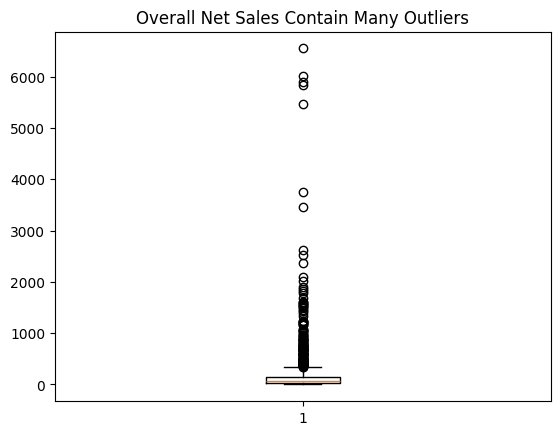

In [18]:
# get net sales chart
e.get_sales_dist(df)

* There are a large number of extreme outliers in net sales
* Customers will be separated into groups using the IQR method
* Customers with net sales of more than 1.5 times the IQR higher than the 75th percentile are designated high spenders
* Other customers are designated moderate spenders

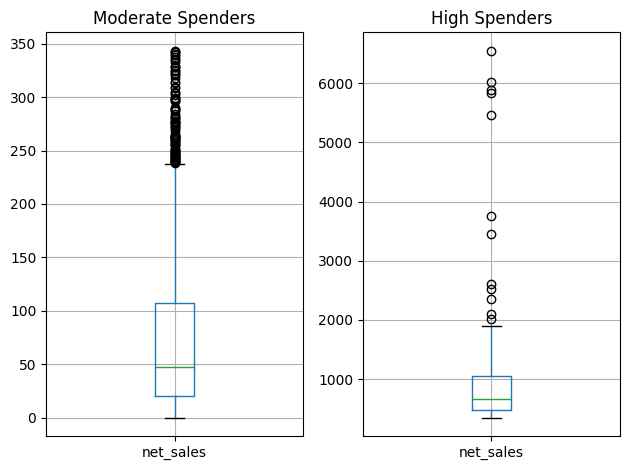

In [19]:
# get high/mod chart
df_mod, df_high = e.get_high_mod_sales(df)
e.get_grouped_sales_dists(df_mod, df_high)

Moderate Spenders Group
* Contains many outliers
* Outliers seem evenly distributed
* Range is much narrower than overall group

High Spenders
* Large range and variance
* There is some clustering of outliers around 6,000 and between 2,000 and 3,000

### How do different spending groups affect total sales?

In [20]:
# get spender sales printout
e.get_spending_effects(df, df_mod, df_high)

Moderate Spenders represent 89.0% of total customers and 40.0% of total net sales
High Spenders represent 11.0% of total customers and 60.0% of total net sales


* The majority of net spending comes from a small number of high spending customers
* Removing these 'outliers' would remove 60% of total net sales
* Perhaps examining both high and moderate spenders will yield some insights

### Is there a relationship between purchase group and net sales for high and moderate spending customers?

In [21]:
# get mod sales chart
e.get_major_sales(df_high)

,all_customers,board_games,modeling_supplies,role_playing_games,minis_models,trading_card_games
Customers,167,69,62,36,71,117
Mean Sales,987,1223,1194,1380,1245,1108
Standard Deviation Sales,1036,1363,1249,1349,1321,1175


In [22]:
# get major sales chart
e.get_major_sales(df_mod)

,all_customers,board_games,modeling_supplies,role_playing_games,minis_models,trading_card_games
Customers,1419,278,212,98,183,468
Mean Sales,76,111,99,129,109,103
Standard Deviation Sales,76,79,86,80,87,88


* The above table shows columns representing each purchase group describing the total number of customers and the mean and standard deviation of net sales for each customer group
* the same phenomenon of outliers skewing the mean of the category groups exists in each division
* it is unlikely that measures of central tendency will paint an accurate picture of each individual group due to outliers
* Differences in means among groups may still suggest useful insights

* Customers who buy trading card games make up 70% of high spending group

* Customers who buy role playing games spend more on average than any other group
* Customers who buy role playing games are also the smallest customer group

# Conclusion

This local game store serves a wide variety of customers both in terms of interest and spending. Roughly ⅓ of total customers or less have made a purchase from categories representing major gaming interests and the top 11% of spenders account for 60% of net sales from loyalty program members. The following discussion describes groups of gamers that have made at least one purchase in each category. There is significant overlap between groups.

Board gamers have the most diversified interests as board games do not share a strong relationship with many other categories, though they are more likely to buy role playing games than non-board gamers.

Trading card gamers are more likely to stay within their own group as there is a significant negative relationship between trading card games and every other interest group. However they are likely the store's largest source of revenue as they make up the store’s largest interest group and make up 70% of the store's top spending customers. Gamers in this group are more likely to buy accessories and concessions than gamers not in this group.

Role playing gamers are likely a major driver of sales in other categories. Role playing gamers are nearly 3 times as likely to buy accessories, 4 times as likely to buy minis models, and 2 times as likely to buy modeling supplies as non-role playing gamers. Role playing gamers spend the most on average and are the smallest customer group.

Minis models gamers likely comprised primarily of “war gamers” and “role playing gamers,” each buying models to support their respective interests. Strong driver of modeling supplies as they are 8 times as likely to buy modeling supplies as non-minis models gamers. 

Modeling supplies gamers are those who like to assemble, paint, and otherwise decorate the models used in their games. Strongly connected with minis models sales of each likely drive sales of the other though the stronger direction is likely minis models to modeling supplies. Gamers in this group are 8 times more likely to buy minis models.

## Recommendations

Continue to promote trading card games as this is likely the store's largest source of revenue. Gamers from this group are the store’s largest interest group and make up 70% of the store's top spending customers. Attempt to cross-sell related accessories such as sleeves, playmats, and binders to increase sales. Gamers in this group have an increased likelihood to buy accessories.

Begin initiative to promote role playing games. Role playing games drive purchases in other categories particularly accessories, minis models, and modeling supplies. Role players also spend more on average than any other interest group and are the smallest in number. For these reasons I believe attracting more gamers in this group represents the greatest possibility for increasing sales. Popular organized activities such as D&D Adventure League might be a good way to do this. Attempt to cross-sell related accessories and models. Gamers in this group are 3-4 times more likely to buy these items than non-role playing gamers.